###Developed a Speech Emotion Recognition system using MFCC-based audio feature extraction and deep learning models, achieving XX% classification accuracy on the RAVDESS dataset.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

os.listdir('/content/drive/MyDrive/ML_Projects')

['audio_speech_actors_01-24.zip.zip']

In [3]:
import zipfile

zip_path = "/content/drive/MyDrive/ML_Projects/audio_speech_actors_01-24.zip.zip"

extract_path = "/content/ravdess"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [4]:
import os

os.listdir('/content/ravdess')

['Actor_15',
 'Actor_14',
 'Actor_09',
 'Actor_22',
 'Actor_05',
 'Actor_21',
 'audio_speech_actors_01-24',
 'Actor_12',
 'Actor_23',
 'Actor_11',
 'Actor_08',
 'Actor_24',
 'Actor_10',
 'Actor_04',
 'Actor_20',
 'Actor_17',
 'Actor_02',
 'Actor_16',
 'Actor_18',
 'Actor_01',
 'Actor_07',
 'Actor_19',
 'Actor_06',
 'Actor_13',
 'Actor_03']

In [5]:
count = 0

for root, dirs, files in os.walk('/content/ravdess'):
    for file in files:
        if file.endswith('.wav'):
            count += 1

print("Total Audio Files:", count)

Total Audio Files: 2880


In [6]:
speech_path = "/content/ravdess/audio_speech_actors_01-24"

count = 0

for root, dirs, files in os.walk(speech_path):
    for file in files:
        if file.endswith(".wav"):
            count += 1

print(count)

1440


In [7]:
!pip install librosa -q

In [8]:
import librosa

sample_file = "/content/ravdess/Actor_01/03-01-01-01-01-01-01.wav"

audio, sr = librosa.load(sample_file)

print("Audio Shape:", audio.shape)
print("Sample Rate:", sr)

Audio Shape: (72838,)
Sample Rate: 22050


In [9]:
import os

speech_path = "/content/ravdess/audio_speech_actors_01-24"

found_files = []
for root, dirs, files in os.walk(speech_path):
    for file in files:
        if file.endswith('.wav'):
            found_files.append(file)
            if len(found_files) >= 5:
                break
    if len(found_files) >= 5:
        break

for file_name in found_files:
    print(file_name)

03-01-01-01-02-01-15.wav
03-01-05-02-02-02-15.wav
03-01-03-01-02-01-15.wav
03-01-05-02-01-02-15.wav
03-01-03-01-01-02-15.wav


In [10]:
emotion_dict = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

In [11]:
import pandas as pd
import os

paths = []
emotions = []

for root, dirs, files in os.walk(speech_path):

    for file in files:

        if file.endswith(".wav"):

            emotion_code = file.split("-")[2]

            emotion = emotion_dict[emotion_code]

            paths.append(os.path.join(root, file))
            emotions.append(emotion)

df = pd.DataFrame({
    "path": paths,
    "emotion": emotions
})

df.head()

,path,emotion
0,/content/ravdess/audio_speech_actors_01-24/Act...,neutral
1,/content/ravdess/audio_speech_actors_01-24/Act...,angry
2,/content/ravdess/audio_speech_actors_01-24/Act...,happy
3,/content/ravdess/audio_speech_actors_01-24/Act...,angry
4,/content/ravdess/audio_speech_actors_01-24/Act...,happy


In [12]:
print(df.shape)

(1440, 2)


In [13]:
df['emotion'].value_counts()

,count
emotion,
angry,192
happy,192
surprised,192
calm,192
fearful,192
sad,192
disgust,192
neutral,96


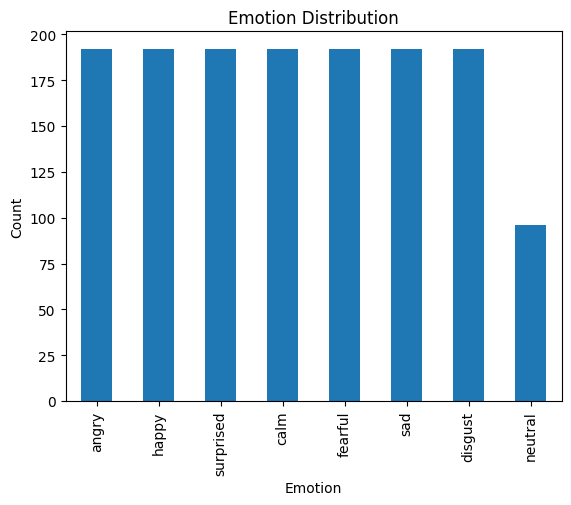

In [14]:
import matplotlib.pyplot as plt

df['emotion'].value_counts().plot(kind='bar')

plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

In [17]:
import numpy as np
def extract_features(file_path):

    audio, sr = librosa.load(file_path)

    # MFCC Features
    mfccs = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )
    mfccs = np.mean(mfccs.T, axis=0)

    # Additional Audio Features
    zcr = np.mean(
        librosa.feature.zero_crossing_rate(audio)
    )

    rms = np.mean(
        librosa.feature.rms(y=audio)
    )

    spectral_centroid = np.mean(
        librosa.feature.spectral_centroid(
            y=audio,
            sr=sr
        )
    )

    # Combine All Features
    features = np.hstack([
        mfccs,
        zcr,
        rms,
        spectral_centroid
    ])

    return features

In [18]:
sample_features = extract_features(df.iloc[0]['path'])

print(sample_features.shape)

(43,)


In [19]:
import numpy as np
X = []
y = []

for index, row in df.iterrows():

    features = extract_features(row['path'])

    X.append(features)
    y.append(row['emotion'])

X = np.array(X)
y = np.array(y)

print("Feature Matrix Shape:", X.shape)
print("Labels Shape:", y.shape)

Feature Matrix Shape: (1440, 43)
Labels Shape: (1440,)


In [20]:
## encode labels
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print(encoder.classes_)

['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape)
print(X_test.shape)

(1152, 43)
(288, 43)


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:

## random forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [24]:
y_pred = rf.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.5729166666666666


In [26]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

       angry       0.68      0.71      0.69        38
        calm       0.56      0.79      0.65        38
     disgust       0.49      0.53      0.51        38
     fearful       0.74      0.59      0.66        39
       happy       0.50      0.38      0.43        39
     neutral       0.70      0.37      0.48        19
         sad       0.46      0.45      0.45        38
   surprised       0.58      0.67      0.62        39

    accuracy                           0.57       288
   macro avg       0.59      0.56      0.56       288
weighted avg       0.58      0.57      0.57       288



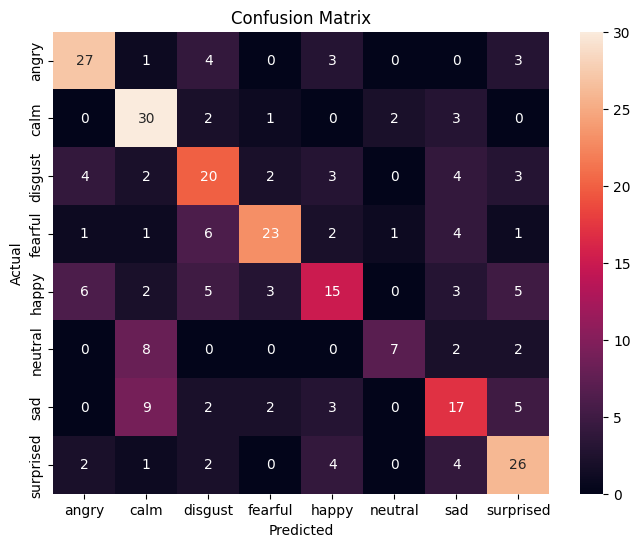

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [28]:
import joblib

joblib.dump(rf, "speech_emotion_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [29]:
sample_path = df.iloc[10]['path']

feature = extract_features(sample_path)

feature = feature.reshape(1, -1)

feature = scaler.transform(feature)

prediction = rf.predict(feature)

print(
    "Predicted Emotion:",
    encoder.inverse_transform(prediction)[0]
)

Predicted Emotion: fearful


In [30]:
sample_path = df.iloc[200]['path']

feature = extract_features(sample_path)

feature = feature.reshape(1, -1)

feature = scaler.transform(feature)

prediction = rf.predict(feature)

print(
    "Predicted Emotion:",
    encoder.inverse_transform(prediction)[0]
)

Predicted Emotion: angry


In [31]:
##Convert Labels for Neural Network
from tensorflow.keras.utils import to_categorical

num_classes = len(np.unique(y_encoded))

y_train_nn = to_categorical(y_train, num_classes)
y_test_nn = to_categorical(y_test, num_classes)

print(y_train_nn.shape)
print(y_test_nn.shape)


(1152, 8)
(288, 8)


In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([

    Dense(256, activation='relu', input_shape=(43,)),

    Dropout(0.3),

    Dense(128, activation='relu'),

    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        11,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,936 (206.78 KB)

 Trainable params: 52,936 (206.78 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [34]:
history = model.fit(
    X_train,
    y_train_nn,
    validation_data=(X_test, y_test_nn),
    epochs=30,
    batch_size=32
)

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1866 - loss: 2.0372 - val_accuracy: 0.2639 - val_loss: 1.8921
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3125 - loss: 1.7973 - val_accuracy: 0.2847 - val_loss: 1.7503
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3559 - loss: 1.6729 - val_accuracy: 0.3750 - val_loss: 1.6315
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4141 - loss: 1.5835 - val_accuracy: 0.4028 - val_loss: 1.5385
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4384 - loss: 1.4704 - val_accuracy: 0.4340 - val_loss: 1.4724
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4861 - loss: 1.3661 - val_accuracy: 0.4444 - val_loss: 1.4063
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5165 - loss: 1.2972 - val_accuracy: 0.4757 - val_loss: 1.3741
Epoch 8/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5460 - loss: 1.2137 - val_accuracy: 0.4861 - val_loss:

In [35]:
loss, accuracy = model.evaluate(
    X_test,
    y_test_nn,
    verbose=0
)

print("Neural Network Accuracy:", accuracy)

Neural Network Accuracy: 0.6423611044883728


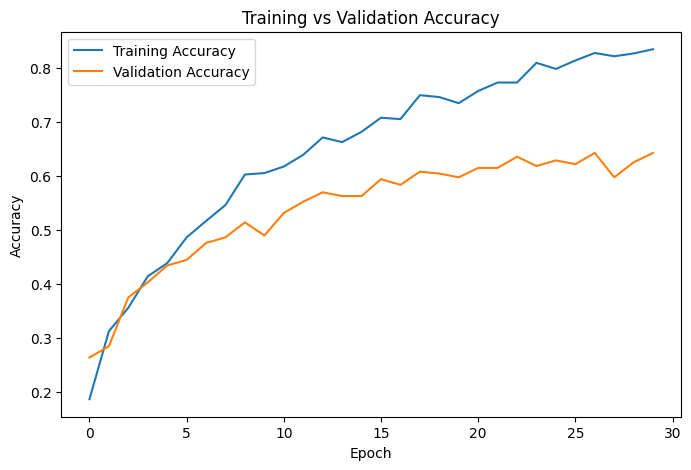

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [37]:
nn_predictions = model.predict(X_test)

y_pred_nn = np.argmax(nn_predictions, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [38]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_nn,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

       angry       0.70      0.79      0.74        38
        calm       0.65      0.82      0.72        38
     disgust       0.67      0.58      0.62        38
     fearful       0.72      0.67      0.69        39
       happy       0.69      0.56      0.62        39
     neutral       0.38      0.32      0.34        19
         sad       0.52      0.58      0.55        38
   surprised       0.68      0.67      0.68        39

    accuracy                           0.64       288
   macro avg       0.63      0.62      0.62       288
weighted avg       0.64      0.64      0.64       288



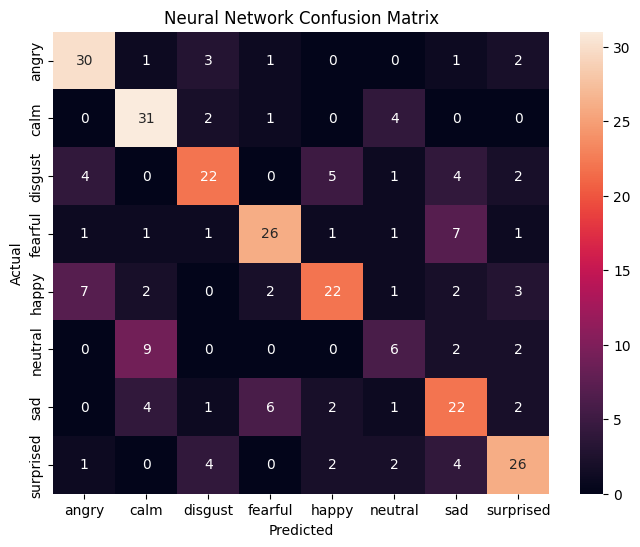

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_nn = confusion_matrix(y_test, y_pred_nn)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_nn,
    annot=True,
    fmt='d',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Neural Network Confusion Matrix")

plt.show()

In [40]:
rf_accuracy = accuracy_score(y_test, y_pred)

nn_accuracy = accuracy_score(y_test, y_pred_nn)

comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Neural Network'],
    'Accuracy': [rf_accuracy, nn_accuracy]
})

comparison

,Model,Accuracy
0,Random Forest,0.572917
1,Neural Network,0.642361


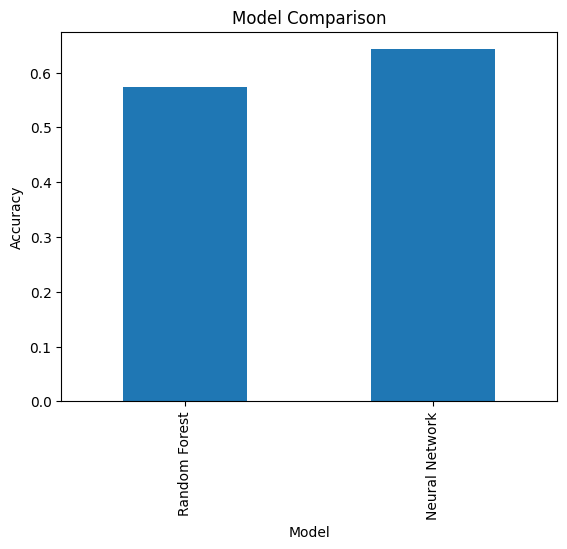

In [41]:


comparison.plot(
    x='Model',
    y='Accuracy',
    kind='bar',
    legend=False
)

plt.title("Model Comparison")
plt.ylabel("Accuracy")

plt.show()

In [42]:
model.save("speech_emotion_nn.h5")

In [43]:
sample_path = df.iloc[50]['path']

feature = extract_features(sample_path)

feature = feature.reshape(1, -1)

feature = scaler.transform(feature)

prediction = model.predict(feature)

emotion = encoder.inverse_transform(
    [np.argmax(prediction)]
)

print("Predicted Emotion:", emotion[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Predicted Emotion: happy


In [44]:
sample_path = df.iloc[200]['path']

feature = extract_features(sample_path)

feature = feature.reshape(1, -1)

feature = scaler.transform(feature)

prediction = model.predict(feature)

emotion = encoder.inverse_transform(
    [np.argmax(prediction)]
)

print("Predicted Emotion:", emotion[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted Emotion: angry


In [93]:
sample_indices = [10, 205, 500, 1, 100]

for idx in sample_indices:

    feature = extract_features(df.iloc[idx]['path'])

    feature = feature.reshape(1, -1)

    feature = scaler.transform(feature)

    prediction = model.predict(feature)

    emotion = encoder.inverse_transform(
        [np.argmax(prediction)]
    )[0]

    actual = df.iloc[idx]['emotion']

    print(f"Actual: {actual} | Predicted: {emotion}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Actual: fearful | Predicted: fearful
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Actual: calm | Predicted: calm
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Actual: disgust | Predicted: disgust
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Actual: angry | Predicted: angry
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Actual: disgust | Predicted: disgust
